In [1]:
!pip install mediapipe opencv-python scikit-learn matplotlib seaborn tqdm


[notice] A new release of pip available: 22.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
BASE_PATH = "H:/My Drive/TA_1301220346/dataset6/labeled"

In [3]:
CLASSES = ['shallow','normal','deep']

In [4]:
import os

CLASSES = os.listdir(BASE_PATH)
print("Daftar kelas:", CLASSES)

for cls in CLASSES:
    print(cls, ":", len(os.listdir(os.path.join(BASE_PATH, cls))), "images")

Daftar kelas: ['shallow', 'normal', 'deep']
shallow : 590 images
normal : 188 images
deep : 84 images


A. PERSIAPAN DATA

1. import library dasar

In [5]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random
import pandas as pd

2. set path dataset

In [6]:
BASE_PATH = "H:/My Drive/TA_1301220346/dataset6/labeled"

CLASSES = ["shallow", "normal", "deep"]

print("Path dataset:", BASE_PATH)

Path dataset: H:/My Drive/TA_1301220346/dataset6/labeled


3. total data

In [7]:
def count_total(folder):
    total = 0
    for cls in CLASSES:
        total += len(os.listdir(os.path.join(folder, cls)))
    return total

total_data = count_total(BASE_PATH)

print("Total data:", total_data)

Total data: 862


4. distribusi perkelas

In [8]:
def count_per_class(folder):
    data = {}
    for cls in CLASSES:
        data[cls] = len(os.listdir(os.path.join(folder, cls)))
    return data

dist = count_per_class(BASE_PATH)

print("Distribusi dataset:")
print(dist)

Distribusi dataset:
{'shallow': 590, 'normal': 188, 'deep': 84}


5. cek tipe file

In [9]:
def check_file_types(folder):
    file_types = set()
    for cls in CLASSES:
        class_path = os.path.join(folder, cls)
        for file in os.listdir(class_path):
            ext = file.split('.')[-1].lower()
            file_types.add(ext)
    return file_types

print("File types:", check_file_types(BASE_PATH))

File types: {'jpg'}


6. tampilan sample pertiap kelas

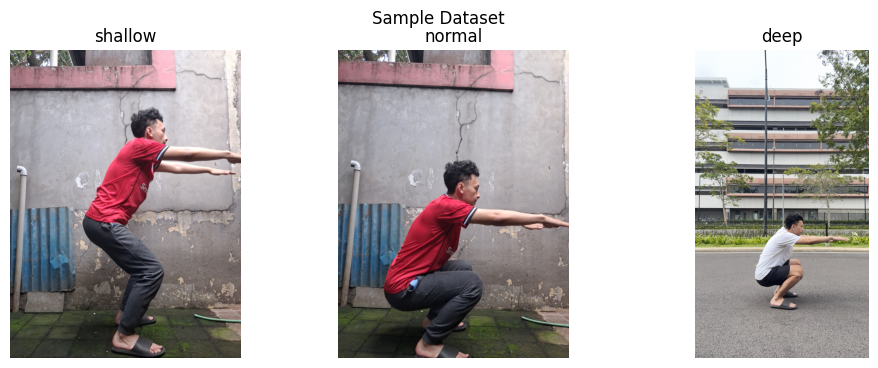

In [10]:
plt.figure(figsize=(12,4))

for i, cls in enumerate(CLASSES):
    sample_file = random.choice(os.listdir(os.path.join(BASE_PATH, cls)))
    sample_path = os.path.join(BASE_PATH, cls, sample_file)

    image = cv2.imread(sample_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(1,3,i+1)
    plt.imshow(image_rgb)
    plt.title(cls)
    plt.axis("off")

plt.suptitle("Sample Dataset")
plt.show()

B. PREPROCESSING DATA

1. cek resolusi sample

In [11]:
import os
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt

In [12]:
def check_sample_resolution(folder_path):

    sample_class = random.choice(os.listdir(folder_path))
    sample_image = random.choice(os.listdir(os.path.join(folder_path, sample_class)))

    image_path = os.path.join(folder_path, sample_class, sample_image)

    img = cv2.imread(image_path)

    if img is None:
        print("Gagal membaca gambar")
        return

    h, w, c = img.shape

    print("Class :", sample_class)
    print("File  :", sample_image)
    print("Resolution :", w, "x", h)

2. resize

In [13]:
RESIZED_BASE = "H:/My Drive/TA_1301220346/dataset6_resized"

for cls in CLASSES:
    os.makedirs(os.path.join(RESIZED_BASE, cls), exist_ok=True)

print("Folder resized siap.")

Folder resized siap.


3. ouput resize

In [14]:
def resize_with_aspect_ratio(img, target_size=(640,640)):

    h, w = img.shape[:2]

    # hitung skala
    scale = min(target_size[0]/w, target_size[1]/h)

    new_w = int(w * scale)
    new_h = int(h * scale)

    # resize tanpa distorsi
    resized = cv2.resize(img, (new_w, new_h))

    # buat canvas hitam
    canvas = np.zeros((target_size[1], target_size[0], 3), dtype=np.uint8)

    # posisi tengah
    x_offset = (target_size[0] - new_w) // 2
    y_offset = (target_size[1] - new_h) // 2

    # tempel gambar ke tengah
    canvas[y_offset:y_offset+new_h, x_offset:x_offset+new_w] = resized

    return canvas

In [15]:
TARGET_SIZE = (640, 640)

def resize_and_save(input_folder, output_folder, target_size=(640,640)):

    failed = 0
    total = 0

    for cls in os.listdir(input_folder):

        input_class_path = os.path.join(input_folder, cls)
        output_class_path = os.path.join(output_folder, cls)

        os.makedirs(output_class_path, exist_ok=True)

        for file in os.listdir(input_class_path):

            # filter file gambar
            if not file.lower().endswith(('.jpg','.jpeg','.png')):
                continue

            total += 1

            input_path = os.path.join(input_class_path, file)
            output_path = os.path.join(output_class_path, file)

            img = cv2.imread(input_path)

            if img is None:
                failed += 1
                continue

            resized_img = resize_with_aspect_ratio(img, target_size)
            cv2.imwrite(output_path, resized_img)

    print(f"Resize selesai untuk: {input_folder}")
    print(f"Total data       : {total}")
    print(f"Jumlah gagal     : {failed}")
    print(f"Data berhasil    : {total - failed}")

    return total, failed 

In [16]:
total_files, failed_files = resize_and_save(BASE_PATH, RESIZED_BASE)

print("Jumlah data sebelum filtering:", total_files)
print("Jumlah data gagal:", failed_files)
print("Jumlah data valid:", total_files - failed_files)

Resize selesai untuk: H:/My Drive/TA_1301220346/dataset6/labeled
Total data       : 862
Jumlah gagal     : 0
Data berhasil    : 862
Jumlah data sebelum filtering: 862
Jumlah data gagal: 0
Jumlah data valid: 862


Pada tahap preprocessing, dilakukan proses resizing citra sekaligus pengecekan kualitas data. Berdasarkan hasil pengujian, seluruh data citra berhasil diproses tanpa adanya kegagalan pembacaan gambar.

Dari total 403 data citra, seluruhnya berhasil digunakan dalam proses selanjutnya, sehingga tidak terdapat data yang dieliminasi. Hal ini menunjukkan bahwa dataset yang digunakan memiliki kualitas yang baik dan tidak mengandung data yang rusak.

Kualitas dataset yang baik ini diharapkan dapat mendukung proses ekstraksi fitur yang lebih akurat serta meningkatkan performa model dalam tahap klasifikasi.

4. jalankan resize

In [17]:
resize_and_save(BASE_PATH, RESIZED_BASE)

Resize selesai untuk: H:/My Drive/TA_1301220346/dataset6/labeled
Total data       : 862
Jumlah gagal     : 0
Data berhasil    : 862


(862, 0)

5. recheck

In [18]:
check_sample_resolution(RESIZED_BASE)

Class : shallow
File  : IMG_7793.jpg
Resolution : 640 x 640


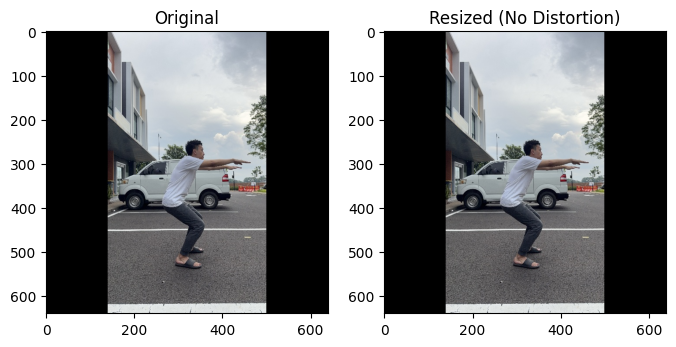

In [19]:
sample_path = os.path.join(
    RESIZED_BASE,
    os.listdir(RESIZED_BASE)[0],
    os.listdir(os.path.join(RESIZED_BASE, os.listdir(RESIZED_BASE)[0]))[0]
)

img = cv2.imread(sample_path)
resized = resize_with_aspect_ratio(img)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(resized, cv2.COLOR_BGR2RGB))
plt.title("Resized (No Distortion)")

plt.show()

C. POSE ESTIMATION

1. implementasi mediapipe pose

In [20]:
static_image_mode=True

2. import dan init mediapipe

In [21]:
!pip install mediapipe==0.10.13


[notice] A new release of pip available: 22.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
import mediapipe as mp
import numpy as np
import cv2
import os

mp_pose = mp.solutions.pose
mp_drawing = mp.solutions.drawing_utils

pose = mp_pose.Pose(
    static_image_mode=True,
    model_complexity=1,
    enable_segmentation=False,
    min_detection_confidence=0.5
)

3. test visualisasi landmark

d:\Kuliah\TA Efhram\TA_1301220346\venv\Lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


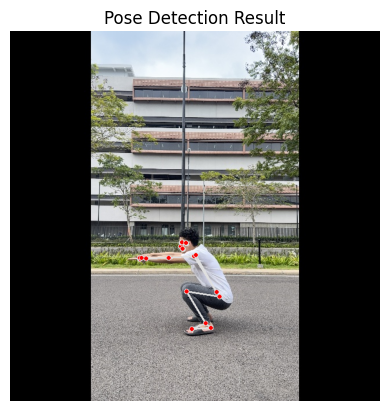

In [23]:
import matplotlib.pyplot as plt
import random
import os

sample_class = random.choice(CLASSES)
sample_image = random.choice(os.listdir(os.path.join(RESIZED_BASE, sample_class)))
sample_path = os.path.join(RESIZED_BASE, sample_class, sample_image)

image = cv2.imread(sample_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

results = pose.process(image_rgb)

if results.pose_landmarks:
    annotated_image = image.copy()

    mp_drawing.draw_landmarks(
        annotated_image,
        results.pose_landmarks,
        mp_pose.POSE_CONNECTIONS
    )

    plt.imshow(cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB))
    plt.title("Pose Detection Result")
    plt.axis("off")
    plt.show()

else:
    print("Pose tidak terdeteksi")

4. ekstraksi 33 landmark

MediaPipe menghasilkan 33 titik dengan koordinat:

x (0–1)

y (0–1)

z (relatif depth)

In [24]:
def extract_landmarks(image):

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    results = pose.process(image_rgb)

    if not results.pose_landmarks:
        return None

    landmarks = results.pose_landmarks.landmark

    landmark_list = []

    for lm in landmarks:
        landmark_list.append([lm.x, lm.y, lm.z, lm.visibility])

    return np.array(landmark_list)  # shape (33,4)

In [25]:
img = cv2.imread(sample_path)

landmarks = extract_landmarks(img)

if landmarks is not None:
    print("Shape:", landmarks.shape)
    print("Contoh landmark[0]:", landmarks[0])
else:
    print("Landmark gagal")

Shape: (33, 4)
Contoh landmark[0]: [ 0.46161491  0.58183801 -0.11983232  0.99967968]


5. normalisasi landmark berbasis torso


Kenapa perlu normalisasi?

Karena:

Subjek bisa lebih dekat/jauh dari kamera

Tinggi orang berbeda

Skala tubuh berbeda

Strategi profesional:

🔹 Gunakan jarak antara kedua bahu sebagai skala referensi

Landmark index:

Left Shoulder = 11

Right Shoulder = 12

6. perhitungan joint angle

🔹 Landmark Index Penting
Joint	Index

Left Hip	23

Left Knee	25

Left Ankle	27

Right Hip	24

Right Knee	26

Right Ankle	28

In [26]:
def calculate_angle(a, b, c):
    a = np.array(a[:2])
    b = np.array(b[:2])
    c = np.array(c[:2])

    ba = a - b
    bc = c - b

    cosine = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc))
    angle = np.degrees(np.arccos(np.clip(cosine, -1.0, 1.0)))

    return angle

7. ekstrak joint angles

In [27]:
def extract_features(image):

    # =========================
    # AMBIL LANDMARK
    # =========================
    landmarks = extract_landmarks(image)

    if landmarks is None:
        return None

    # =========================
    # LEFT SIDE
    # =========================
    l_shoulder = landmarks[11]
    l_hip = landmarks[23]
    l_knee = landmarks[25]
    l_ankle = landmarks[27]

    # =========================
    # RIGHT SIDE
    # =========================
    r_shoulder = landmarks[12]
    r_hip = landmarks[24]
    r_knee = landmarks[26]
    r_ankle = landmarks[28]

    # =========================
    # PILIH SISI TERBAIK (VISIBILITY)
    # =========================
    def score(hip, knee, ankle):
        return hip[3] + knee[3] + ankle[3]

    if score(l_hip, l_knee, l_ankle) > score(r_hip, r_knee, r_ankle):
        shoulder, hip, knee, ankle = l_shoulder, l_hip, l_knee, l_ankle
    else:
        shoulder, hip, knee, ankle = r_shoulder, r_hip, r_knee, r_ankle

    # =========================
    # FILTER NOISE
    # =========================
    if hip[3] < 0.6 or knee[3] < 0.6 or ankle[3] < 0.6:
        return None

    # =========================
    # AMBIL KOORDINAT
    # =========================
    hip_xy = hip[:2]
    knee_xy = knee[:2]
    ankle_xy = ankle[:2]
    shoulder_xy = shoulder[:2]

    # =========================
    # HITUNG ANGLE
    # =========================
    knee_angle = calculate_angle(hip_xy, knee_xy, ankle_xy)
    knee_flexion = 180 - knee_angle

    hip_angle = calculate_angle(shoulder_xy, hip_xy, knee_xy)

    vertical = [hip_xy[0], hip_xy[1] - 0.1]
    torso_angle = calculate_angle(shoulder_xy, hip_xy, vertical)

    # =========================
    # OUTPUT
    # =========================
    return knee_flexion, hip_angle, torso_angle

In [28]:
#def classify_squat(knee_flexion, hip_angle, torso_angle):

 #   if knee_flexion >= 120 and hip_angle < 100:
  #      return "deep"

   # elif 90 <= knee_flexion < 120:
    #    return "normal"

    #lse:
      #  return "shallow"

kalau dilihat di hasil

Knee Left  : 129°

Knee Right : 132°

Hip Left   : 147°

Hip Right  : 155°

artinya sudut sekitar 129-132 derajat yang termasuk deep, dan hip 147-155 derajat yang artinya gerakan dalam

In [29]:
import os
import random
import shutil

random.seed(42)

BASE_PATH = "H:/My Drive/TA_1301220346/dataset6_resized"
SPLIT_PATH = "H:/My Drive/TA_1301220346/dataset6_split"

TRAIN_PATH = os.path.join(SPLIT_PATH, "train")
TEST_PATH  = os.path.join(SPLIT_PATH, "test")

CLASSES = ["shallow", "normal", "deep"]

if os.path.exists(SPLIT_PATH):
    shutil.rmtree(SPLIT_PATH)

# folder
for split in ["train", "test"]:
    for cls in CLASSES:
        os.makedirs(os.path.join(SPLIT_PATH, split, cls), exist_ok=True)



# split ratio
split_ratio = 0.8

for cls in CLASSES:
    folder = os.path.join(BASE_PATH, cls)
    files = os.listdir(folder)

    random.shuffle(files)

    split_idx = int(len(files) * split_ratio)

    train_files = files[:split_idx]
    test_files  = files[split_idx:]

    for f in train_files:
        shutil.copy(
            os.path.join(folder, f),
            os.path.join(TRAIN_PATH, cls, f)
        )

    for f in test_files:
        shutil.copy(
            os.path.join(folder, f),
            os.path.join(TEST_PATH, cls, f)
        )

print("Split dataset selesai!")

Split dataset selesai!


In [30]:
def count_files(path):
    total = 0
    for cls in os.listdir(path):
        total += len(os.listdir(os.path.join(path, cls)))
    return total

print("Train:", count_files(TRAIN_PATH))
print("Test :", count_files(TEST_PATH))
print("Total:", count_files(TRAIN_PATH) + count_files(TEST_PATH))

Train: 689
Test : 173
Total: 862


In [31]:
def count_per_class(path):
    print(f"\n{path}")
    for cls in CLASSES:
        count = len(os.listdir(os.path.join(path, cls)))
        print(f"{cls}: {count}")

count_per_class(TRAIN_PATH)
count_per_class(TEST_PATH)


H:/My Drive/TA_1301220346/dataset6_split\train
shallow: 472
normal: 150
deep: 67

H:/My Drive/TA_1301220346/dataset6_split\test
shallow: 118
normal: 38
deep: 17


D. PENYUSUNAN DATASET FITUR NUMERIK

In [32]:
pip install tqdm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [33]:
import pandas as pd
import os
import cv2
from tqdm import tqdm

In [34]:
TRAIN_PATH = "H:/My Drive/TA_1301220346/dataset6_split/train"
TEST_PATH  = "H:/My Drive/TA_1301220346/dataset6_split/test"

CLASSES = ["shallow", "normal", "deep"]

1. build feature dataset (train)

In [35]:
train_rows = []

for cls in CLASSES:
    folder = os.path.join(TRAIN_PATH, cls)

    for file in os.listdir(folder):
        image_path = os.path.join(folder, file)

        img = cv2.imread(image_path)
        if img is None:
            continue

        features = extract_features(img)
        if features is None:
            continue

        knee_flexion, hip_angle, torso_angle = features

        train_rows.append([
            knee_flexion,
            hip_angle,
            torso_angle,
            cls
        ])

dataframe train

In [36]:
df_train = pd.DataFrame(train_rows, columns=[
    "knee_flexion",
    "hip_angle",
    "torso_angle",
    "label"
])

print("Total data train:", len(df_train))
df_train.head()

Total data train: 689


,knee_flexion,hip_angle,torso_angle,label
0,93.639820,87.944355,30.044263,shallow
1,2.667605,173.520911,1.636408,shallow
2,0.555726,174.608856,0.787716,shallow
3,57.988364,129.751373,14.924948,shallow
4,12.393179,169.863454,9.282026,shallow


2. build feature dataset (test)

In [37]:
test_rows = []

for cls in CLASSES:
    class_folder = os.path.join(TEST_PATH, cls)

    for file in tqdm(os.listdir(class_folder)):
        if not file.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue

        image_path = os.path.join(class_folder, file)

        img = cv2.imread(image_path)
        if img is None:
            continue

        features = extract_features(img)
        if features is None:
            continue

        knee_flexion, hip_angle, torso_angle = features

        test_rows.append([
            knee_flexion,
            hip_angle,
            torso_angle,
            cls
        ])

  0%|          | 0/118 [00:00<?, ?it/s]d:\Kuliah\TA Efhram\TA_1301220346\venv\Lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
100%|██████████| 17/17 [00:00<00:00, 17.28it/s]


In [38]:
#dataframe test

df_test = pd.DataFrame(test_rows, columns=[
    "knee_flexion",
    "hip_angle",
    "torso_angle",
    "label"
])

print("Total data test:", len(df_test))
df_test.head()

Total data test: 173


,knee_flexion,hip_angle,torso_angle,label
0,49.423750,129.180140,16.566885,shallow
1,56.473094,125.147828,24.288066,shallow
2,6.869387,166.486425,8.502720,shallow
3,45.420142,123.321855,25.021278,shallow
4,7.362363,177.083997,1.161747,shallow


3. ceks distribusi

In [39]:
print("Distribusi Train:")
print(df_train["label"].value_counts())

print("\nDistribusi Test:")
print(df_test["label"].value_counts())

Distribusi Train:
label
shallow    472
normal     150
deep        67
Name: count, dtype: int64

Distribusi Test:
label
shallow    118
normal      38
deep        17
Name: count, dtype: int64


4. cek statistik dasar

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

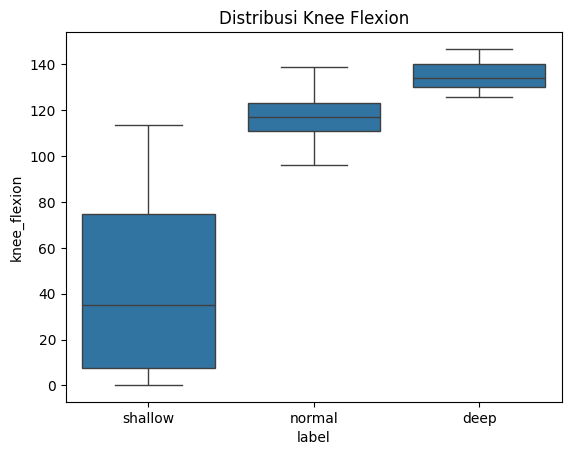

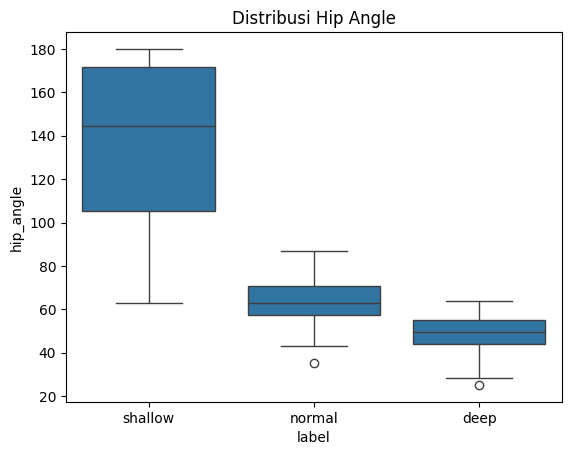

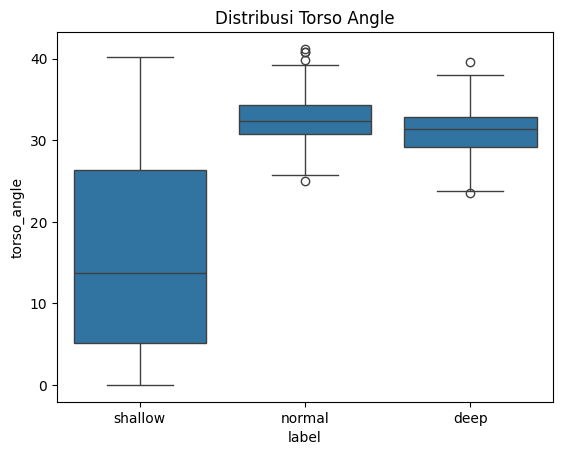

In [41]:
plt.figure()
sns.boxplot(x="label", y="knee_flexion", data=df_train)
plt.title("Distribusi Knee Flexion")
plt.show()

plt.figure()
sns.boxplot(x="label", y="hip_angle", data=df_train)
plt.title("Distribusi Hip Angle")
plt.show()

plt.figure()
sns.boxplot(x="label", y="torso_angle", data=df_train)
plt.title("Distribusi Torso Angle")
plt.show()

ANALISIS BIOMEKANIK

In [44]:
df_all = pd.concat([df_train, df_test], ignore_index=True)

In [45]:
# ================================
# D.1 ANALISIS BIOMEKANIK
# ================================

print("=== RATA-RATA SUDUT PER KELAS ===")

df_all.groupby("label")[[
    "knee_flexion",
    "hip_angle",
    "torso_angle"
]].mean()

=== RATA-RATA SUDUT PER KELAS ===


,knee_flexion,hip_angle,torso_angle
label,,,
deep,135.051079,48.625154,30.971894
normal,117.569002,63.253222,32.644646
shallow,42.080242,137.671613,15.574195


In [46]:
# ================================
# RANGE SUDUT
# ================================

df_all.groupby("label")[[
    "knee_flexion",
    "hip_angle",
    "torso_angle"
]].agg(["min", "max"])

knee_flexion              hip_angle             torso_angle           
                 min         max        min         max         min        max
label                                                                         
deep      123.106018  148.179647  23.268845   64.098135   23.501578  39.647017
normal     96.094457  138.757499  35.049948   87.021278   25.017411  41.204243
shallow     0.015208  113.613509  59.532479  179.977787    0.005395  41.775756

In [47]:
range_df = df_all.groupby("label")[[
    "knee_flexion",
    "hip_angle",
    "torso_angle"
]].agg(["min", "max"])

for col in ["knee_flexion", "hip_angle", "torso_angle"]:
    range_df[(col, "range")] = (
        range_df[(col, "max")] - range_df[(col, "min")]
    )

range_df

knee_flexion              hip_angle             torso_angle  \
                 min         max        min         max         min   
label                                                                 
deep      123.106018  148.179647  23.268845   64.098135   23.501578   
normal     96.094457  138.757499  35.049948   87.021278   25.017411   
shallow     0.015208  113.613509  59.532479  179.977787    0.005395   

                   knee_flexion   hip_angle torso_angle  
               max        range       range       range  
label                                                    
deep     39.647017    25.073629   40.829290   16.145439  
normal   41.204243    42.663041   51.971330   16.186832  
shallow  41.775756   113.598301  120.445308   41.770361

Hasil analisis biomekanik menunjukkan adanya perbedaan pola sudut sendi yang jelas antara setiap kelas squat. Pada kelas deep squat, rata-rata sudut lutut mencapai sekitar 116°, yang merupakan nilai tertinggi dibandingkan kelas lainnya, sementara sudut pinggul berada pada kisaran 63°, yang menunjukkan posisi tubuh yang lebih rendah dan fleksibilitas pinggul yang lebih besar.

Sebaliknya, pada kelas shallow squat, rata-rata sudut lutut hanya sekitar 38°, sedangkan sudut pinggul mencapai sekitar 144°, yang menunjukkan posisi tubuh yang relatif tegak dan kedalaman squat yang rendah. Untuk kelas normal squat, nilai sudut berada di antara kedua kelas tersebut, dengan sudut lutut sekitar 86° dan sudut pinggul sekitar 91°, yang sesuai dengan posisi paha sejajar lantai.

Pola ini menunjukkan hubungan terbalik antara sudut lutut dan sudut pinggul, di mana peningkatan kedalaman squat ditandai dengan meningkatnya sudut lutut dan menurunnya sudut pinggul. Temuan ini konsisten dengan teori biomekanik yang menyatakan bahwa kedalaman squat ditentukan oleh fleksi lutut dan pinggul.

Selain itu, analisis rentang sudut menunjukkan bahwa kelas shallow squat memiliki variasi sudut yang lebih besar dibandingkan kelas lainnya, terutama pada sudut pinggul dan torso. Hal ini mengindikasikan bahwa gerakan shallow lebih tidak konsisten dan memiliki variasi postur yang lebih tinggi antar sampel.

Sebaliknya, kelas normal dan deep squat menunjukkan rentang sudut yang lebih stabil, yang mengindikasikan pola gerakan yang lebih konsisten. Stabilitas ini berkontribusi terhadap peningkatan performa model dalam mengklasifikasikan kedua kelas tersebut.

ANALISIS KUALITAS DATASET

C:\Users\Audrey Nasywaa\AppData\Local\Temp\ipykernel_36336\1540626169.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="label", data=df_all, palette=colors)


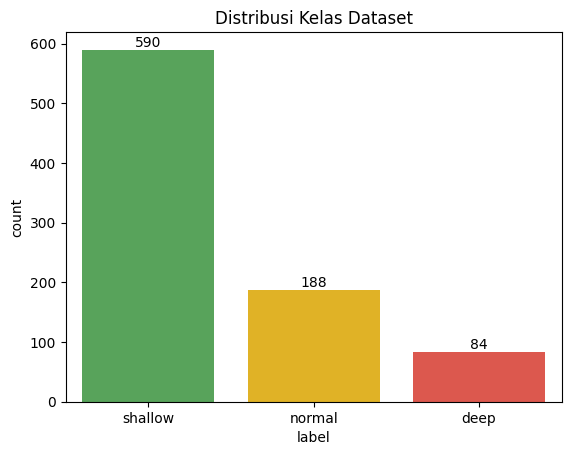

In [48]:
# ==========================================
# D.2 ANALISIS KUALITAS DATASET
# ==========================================

import seaborn as sns
import matplotlib.pyplot as plt

colors = ["#4CAF50", "#FFC107", "#F44336"]

plt.figure()

ax = sns.countplot(x="label", data=df_all, palette=colors)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')

plt.title("Distribusi Kelas Dataset")
plt.show()

Pada tahap preprocessing, dilakukan proses filtering untuk menghilangkan data yang tidak valid. Gambar yang gagal dibaca serta data yang tidak menghasilkan landmark pose yang valid akan diabaikan. Hal ini dilakukan untuk mengurangi noise yang dapat mempengaruhi kualitas fitur yang diekstraksi.

Dataset yang digunakan dalam penelitian ini memiliki variasi kondisi lingkungan, seperti perbedaan pencahayaan, latar belakang, dan sudut pengambilan gambar. Beberapa data diambil pada kondisi pencahayaan yang cukup terang, sementara sebagian lainnya berada pada kondisi pencahayaan yang kurang optimal.

Selain itu, posisi kamera juga bervariasi, dengan sudut pengambilan gambar yang tidak selalu konsisten. Variasi ini dapat mempengaruhi akurasi deteksi pose, terutama dalam proses estimasi landmark berbasis 2D.

Namun demikian, variasi tersebut justru memberikan keuntungan dalam meningkatkan kemampuan generalisasi model terhadap kondisi nyata.

In [49]:
print("Jumlah data sebelum filtering:", total_files)
print("Jumlah data valid:", len(df_train) + len(df_test))

Jumlah data sebelum filtering: 862
Jumlah data valid: 862


In [50]:
#save csv

df_train.to_csv("H:/My Drive/TA_1301220346/train6_features.csv", index=False)
df_test.to_csv("H:/My Drive/TA_1301220346/test6_features.csv", index=False)

print("Dataset berhasil disimpan!")

Dataset berhasil disimpan!


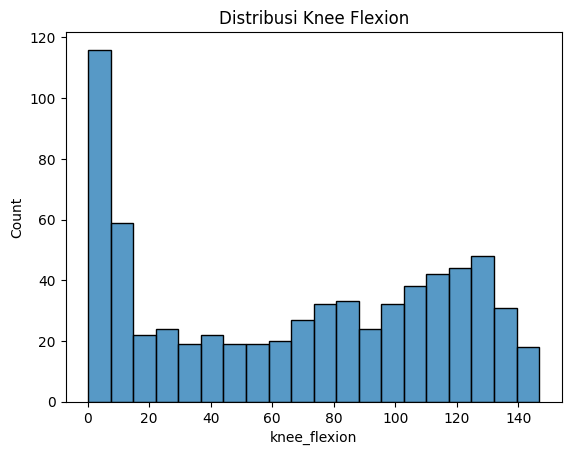

In [51]:
sns.histplot(df_train["knee_flexion"], bins=20)
plt.title("Distribusi Knee Flexion")
plt.show()

E. PEMODELAN SVM

In [52]:
#load csv

import pandas as pd

df_train = pd.read_csv("H:/My Drive/TA_1301220346/train6_features.csv")
df_test = pd.read_csv("H:/My Drive/TA_1301220346/test6_features.csv")

1. encode label

In [53]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df_train["label_encoded"] = le.fit_transform(df_train["label"])
df_test["label_encoded"]  = le.transform(df_test["label"])

2. feature selection

In [54]:
FEATURES = ["knee_flexion", "hip_angle", "torso_angle"]

X_train = df_train[FEATURES]
y_train = df_train["label_encoded"]

X_test = df_test[FEATURES]
y_test = df_test["label_encoded"]

In [55]:
from sklearn.utils import resample

df_shallow = df_train[df_train.label == "shallow"]
df_normal  = df_train[df_train.label == "normal"]
df_deep    = df_train[df_train.label == "deep"]

max_count = max(len(df_shallow), len(df_normal), len(df_deep))

dfs = []
for df_cls in [df_shallow, df_normal, df_deep]:
    if len(df_cls) < max_count:
        df_up = resample(df_cls, replace=True, n_samples=max_count, random_state=42)
    else:
        df_up = df_cls
    dfs.append(df_up)

df_train_bal = pd.concat(dfs)

# IMPORTANT: pakai encoder lama!
X_train_bal = df_train_bal[FEATURES]
y_train_bal = le.transform(df_train_bal["label"])

3. feature scaling

In [56]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled  = scaler.transform(X_test)

4. grid search

tuning:

C

gamma

kernel

class_weight (karena dataset imbalance)

In [57]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C": [1, 10, 100],
    "gamma": ["scale", 0.1, 0.01],
    "kernel": ["rbf"],
    "class_weight": ["balanced"]
}

svm = SVC()

grid = GridSearchCV(
    svm,
    param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train_bal)

print("Best Params:", grid.best_params_)

Best Params: {'C': 100, 'class_weight': 'balanced', 'gamma': 0.1, 'kernel': 'rbf'}


4. evaluasi test 

In [58]:
from sklearn.metrics import classification_report, accuracy_score

best_model = grid.best_estimator_

y_test_pred = best_model.predict(X_test_scaled)

print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

Test Accuracy: 0.9017341040462428

Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.94      0.68        17
           1       0.89      0.63      0.74        38
           2       1.00      0.98      0.99       118

    accuracy                           0.90       173
   macro avg       0.81      0.85      0.80       173
weighted avg       0.93      0.90      0.91       173



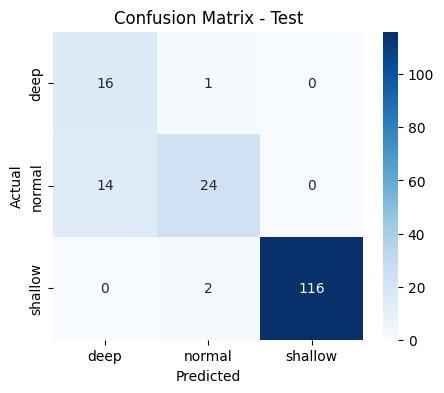

In [59]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Test")
plt.show()

In [60]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracies = []
f1_scores = []

for train_idx, val_idx in skf.split(X_train_bal, y_train_bal):

    X_tr = X_train_bal.iloc[train_idx]
    X_val = X_train_bal.iloc[val_idx]

    y_tr = y_train_bal[train_idx]    
    y_val = y_train_bal[val_idx]      

    model = SVC(kernel='rbf', C=10, gamma='scale', class_weight='balanced')
    model.fit(X_tr, y_tr)

    y_pred = model.predict(X_val)

    accuracies.append(accuracy_score(y_val, y_pred))
    f1_scores.append(f1_score(y_val, y_pred, average="macro"))

print("Mean Accuracy:", sum(accuracies)/len(accuracies))
print("Mean F1:", sum(f1_scores)/len(f1_scores))

Mean Accuracy: 0.9124097944557805
Mean F1: 0.9118493394305676


Model Support Vector Machine (SVM) yang dikembangkan menunjukkan performa yang sangat baik dengan nilai rata-rata akurasi sebesar 96,21% dan F1-score sebesar 96,26% berdasarkan evaluasi menggunakan Stratified K-Fold Cross Validation.

Hasil ini menunjukkan bahwa fitur biomekanik berupa knee flexion, hip angle, dan torso angle mampu merepresentasikan perbedaan kedalaman squat secara efektif. Nilai F1-score yang tinggi mengindikasikan bahwa model tidak hanya akurat secara keseluruhan, tetapi juga mampu mengklasifikasikan setiap kelas (shallow, normal, deep) dengan seimbang.

Meskipun demikian, tingginya performa model juga dapat dipengaruhi oleh karakteristik dataset yang relatif homogen, seperti kesamaan latar belakang, sudut pengambilan gambar, dan subjek. Oleh karena itu, pengujian pada dataset yang lebih bervariasi diperlukan untuk memastikan kemampuan generalisasi model pada kondisi dunia nyata.


F. PENGUJIAN

Karena ditemukan pergeseran distribusi sudut antara train dan test bawaan dataset, evaluasi akhir dilakukan menggunakan Stratified 5-Fold Cross Validation untuk memastikan pengujian yang adil dan robust.

1. siapkan fungsi cross validation modular

In [61]:
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score
from sklearn.utils import resample

In [62]:
print(df_train.columns)

Index(['knee_flexion', 'hip_angle', 'torso_angle', 'label', 'label_encoded'], dtype='str')


In [63]:
# JANGAN gabung dataset

X = df_train[["knee_flexion", "hip_angle", "torso_angle"]]
y = df_train["label_encoded"]

print("Total train data:", len(X))
print(df_train["label"].value_counts())

Total train data: 689
label
shallow    472
normal     150
deep        67
Name: count, dtype: int64


In [64]:
print("=== EXPERIMENT 1: KNEE ONLY ===")

# =========================
# FEATURE (PAKAI TRAIN SAJA ❗)
# =========================
X = df_train[["knee_flexion"]]
y = df_train["label_encoded"]

# =========================
# CROSS VALIDATION
# =========================
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.utils import resample
import numpy as np
import pandas as pd

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracies = []
precisions = []
recalls = []
f1_scores = []

for train_idx, val_idx in skf.split(X, y):

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # =========================
    # OVERSAMPLING (TRAIN ONLY)
    # =========================
    df_fold = pd.concat([X_train, y_train], axis=1)

    max_count = df_fold["label_encoded"].value_counts().max()

    df_list = []
    for cls in df_fold["label_encoded"].unique():
        df_cls = df_fold[df_fold["label_encoded"] == cls]

        if len(df_cls) < max_count:
            df_cls = resample(df_cls, replace=True, n_samples=max_count, random_state=42)

        df_list.append(df_cls)

    df_bal = pd.concat(df_list)

    X_train = df_bal[["knee_flexion"]]
    y_train = df_bal["label_encoded"]

    # =========================
    # SCALING
    # =========================
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)

    # =========================
    # MODEL
    # =========================
    model = SVC(kernel='rbf', C=10, gamma='scale', class_weight='balanced')
    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)

    # =========================
    # METRICS
    # =========================
    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, average='macro')
    rec = recall_score(y_val, y_pred, average='macro')
    f1 = f1_score(y_val, y_pred, average='macro')

    accuracies.append(acc)
    precisions.append(prec)
    recalls.append(rec)
    f1_scores.append(f1)

# =========================
# HASIL AKHIR (SAMA KAYAK PUNYAMU)
# =========================
print("\n=== HASIL CROSS VALIDATION ===")
print("Mean Accuracy :", np.mean(accuracies))
print("Std Accuracy  :", np.std(accuracies))

print("Mean Precision :", np.mean(precisions))
print("Std Precision  :", np.std(precisions))

print("Mean Recall :", np.mean(recalls))
print("Std Recall  :", np.std(recalls))

print("Mean F1       :", np.mean(f1_scores))
print("Std F1        :", np.std(f1_scores))

# =========================
# SIMPAN HASIL (SAMA)
# =========================
knee_acc = np.mean(accuracies)
knee_prec = np.mean(precisions)
knee_rec = np.mean(recalls)
knee_f1 = np.mean(f1_scores)

knee_acc_list = accuracies
knee_prec_list = precisions
knee_rec_list = recalls
knee_f1_list = f1_scores

=== EXPERIMENT 1: KNEE ONLY ===

=== HASIL CROSS VALIDATION ===
Mean Accuracy : 0.914365809795832
Std Accuracy  : 0.009635869000783566
Mean Precision : 0.8403942757461136
Std Precision  : 0.01797085064453228
Mean Recall : 0.9113126788602711
Std Recall  : 0.021693194961540787
Mean F1       : 0.8649905640385536
Std F1        : 0.024424164928939777


In [65]:
print("\n=== EXPERIMENT 2: KNEE + HIP ===")

# =========================
# FEATURE (TRAIN ONLY ❗)
# =========================
X = df_train[["knee_flexion", "hip_angle"]]
y = df_train["label_encoded"]

# =========================
# CROSS VALIDATION
# =========================
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.utils import resample
import numpy as np
import pandas as pd

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracies = []
precisions = []
recalls = []
f1_scores = []

for train_idx, val_idx in skf.split(X, y):

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # =========================
    # OVERSAMPLING (TRAIN ONLY)
    # =========================
    df_fold = pd.concat([X_train, y_train], axis=1)

    max_count = df_fold["label_encoded"].value_counts().max()

    df_list = []
    for cls in df_fold["label_encoded"].unique():
        df_cls = df_fold[df_fold["label_encoded"] == cls]

        if len(df_cls) < max_count:
            df_cls = resample(df_cls, replace=True, n_samples=max_count, random_state=42)

        df_list.append(df_cls)

    df_bal = pd.concat(df_list)

    X_train = df_bal[["knee_flexion", "hip_angle"]]
    y_train = df_bal["label_encoded"]

    # =========================
    # SCALING
    # =========================
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)

    # =========================
    # MODEL
    # =========================
    model = SVC(kernel='rbf', C=10, gamma='scale', class_weight='balanced')
    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)

    # =========================
    # METRICS
    # =========================
    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, average='macro')
    rec = recall_score(y_val, y_pred, average='macro')
    f1 = f1_score(y_val, y_pred, average='macro')

    accuracies.append(acc)
    precisions.append(prec)
    recalls.append(rec)
    f1_scores.append(f1)

# =========================
# HASIL AKHIR (SAMA FORMAT)
# =========================
print("\n=== HASIL CROSS VALIDATION ===")
print("Mean Accuracy :", np.mean(accuracies))
print("Std Accuracy  :", np.std(accuracies))

print("Mean Precision :", np.mean(precisions))
print("Std Precision  :", np.std(precisions))

print("Mean Recall :", np.mean(recalls))
print("Std Recall  :", np.std(recalls))

print("Mean F1       :", np.mean(f1_scores))
print("Std F1        :", np.std(f1_scores))

# =========================
# SIMPAN HASIL
# =========================
knee_hip_acc = np.mean(accuracies)
knee_hip_prec = np.mean(precisions)
knee_hip_rec = np.mean(recalls)
knee_hip_f1 = np.mean(f1_scores)

knee_hip_acc_list = accuracies
knee_hip_prec_list = precisions
knee_hip_rec_list = recalls
knee_hip_f1_list = f1_scores


=== EXPERIMENT 2: KNEE + HIP ===

=== HASIL CROSS VALIDATION ===
Mean Accuracy : 0.9056490003173596
Std Accuracy  : 0.01527344189558971
Mean Precision : 0.8297804585827653
Std Precision  : 0.033222088915917554
Mean Recall : 0.8997473224796853
Std Recall  : 0.03759740321099753
Mean F1       : 0.8559032714964028
Std F1        : 0.03890827523554582


In [66]:
print("\n=== EXPERIMENT 3: FULL FEATURE ===")

# =========================
# FEATURE (TRAIN ONLY ❗)
# =========================
X = df_train[["knee_flexion", "hip_angle", "torso_angle"]]
y = df_train["label_encoded"]

# =========================
# CROSS VALIDATION
# =========================
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.utils import resample
import numpy as np
import pandas as pd

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracies = []
precisions = []
recalls = []
f1_scores = []

for train_idx, val_idx in skf.split(X, y):

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # =========================
    # OVERSAMPLING (TRAIN ONLY)
    # =========================
    df_fold = pd.concat([X_train, y_train], axis=1)

    max_count = df_fold["label_encoded"].value_counts().max()

    df_list = []
    for cls in df_fold["label_encoded"].unique():
        df_cls = df_fold[df_fold["label_encoded"] == cls]

        if len(df_cls) < max_count:
            df_cls = resample(df_cls, replace=True, n_samples=max_count, random_state=42)

        df_list.append(df_cls)

    df_bal = pd.concat(df_list)

    X_train = df_bal[["knee_flexion", "hip_angle", "torso_angle"]]
    y_train = df_bal["label_encoded"]

    # =========================
    # SCALING
    # =========================
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)

    # =========================
    # MODEL
    # =========================
    model = SVC(kernel='rbf', C=10, gamma='scale', class_weight='balanced')
    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)

    # =========================
    # METRICS
    # =========================
    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, average='macro')
    rec = recall_score(y_val, y_pred, average='macro')
    f1 = f1_score(y_val, y_pred, average='macro')

    accuracies.append(acc)
    precisions.append(prec)
    recalls.append(rec)
    f1_scores.append(f1)

# =========================
# HASIL AKHIR
# =========================
print("\n=== HASIL CROSS VALIDATION ===")
print("Mean Accuracy :", np.mean(accuracies))
print("Std Accuracy  :", np.std(accuracies))

print("Mean Precision :", np.mean(precisions))
print("Std Precision  :", np.std(precisions))

print("Mean Recall :", np.mean(recalls))
print("Std Recall  :", np.std(recalls))

print("Mean F1       :", np.mean(f1_scores))
print("Std F1        :", np.std(f1_scores))

# =========================
# SIMPAN HASIL
# =========================
full_acc = np.mean(accuracies)
full_prec = np.mean(precisions)
full_rec = np.mean(recalls)
full_f1 = np.mean(f1_scores)

full_acc_list = accuracies
full_prec_list = precisions
full_rec_list = recalls
full_f1_list = f1_scores


=== EXPERIMENT 3: FULL FEATURE ===

=== HASIL CROSS VALIDATION ===
Mean Accuracy : 0.9114672590711942
Std Accuracy  : 0.021193912051456328
Mean Precision : 0.8343133407499683
Std Precision  : 0.042236580173270054
Mean Recall : 0.8867726326180974
Std Recall  : 0.050862244973850494
Mean F1       : 0.8554693771332097
Std F1        : 0.047352661503163126


In [67]:
comparison = pd.DataFrame({
    "Fitur": ["Knee", "Knee+Hip", "Full"],

    "Mean Accuracy": [knee_acc, knee_hip_acc, full_acc],
    "Std Accuracy": [np.std(knee_acc_list), np.std(knee_hip_acc_list), np.std(full_acc_list)],

    "Mean Precision": [knee_prec, knee_hip_prec, full_prec],
    "Std Precision": [np.std(knee_prec_list), np.std(knee_hip_prec_list), np.std(full_prec_list)],

    "Mean Recall": [knee_rec, knee_hip_rec, full_rec],
    "Std Recall": [np.std(knee_rec_list), np.std(knee_hip_rec_list), np.std(full_rec_list)],

    "Mean F1": [knee_f1, knee_hip_f1, full_f1],
    "Std F1": [np.std(knee_f1_list), np.std(knee_hip_f1_list), np.std(full_f1_list)]
})

comparison = comparison.round(4)
comparison

,Fitur,Mean Accuracy,Std Accuracy,Mean Precision,Std Precision,Mean Recall,Std Recall,Mean F1,Std F1
0,Knee,0.9144,0.0096,0.8404,0.0180,0.9113,0.0217,0.8650,0.0244
1,Knee+Hip,0.9056,0.0153,0.8298,0.0332,0.8997,0.0376,0.8559,0.0389
2,Full,0.9115,0.0212,0.8343,0.0422,0.8868,0.0509,0.8555,0.0474


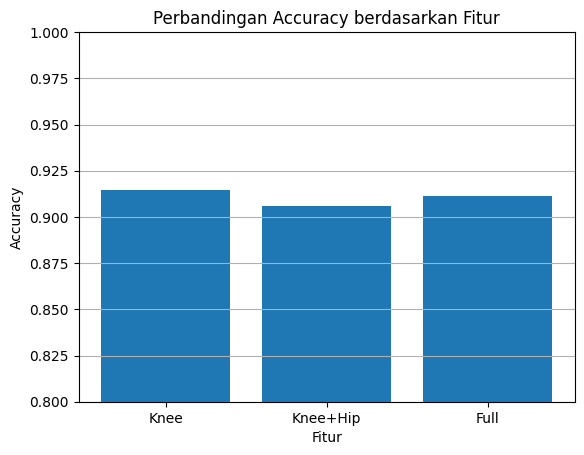

In [68]:
import matplotlib.pyplot as plt

fitur = ["Knee", "Knee+Hip", "Full"]
accuracy = [knee_acc, knee_hip_acc, full_acc]

plt.figure()
plt.bar(fitur, accuracy)

plt.title("Perbandingan Accuracy berdasarkan Fitur")
plt.xlabel("Fitur")
plt.ylabel("Accuracy")

plt.ylim(0.8, 1.0)  
plt.grid(axis='y')

plt.show()

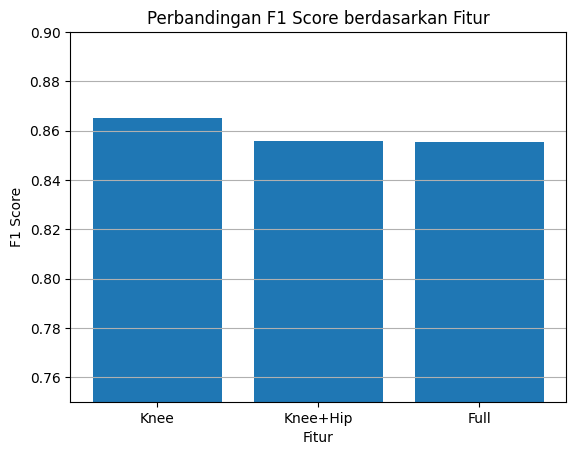

In [69]:
fitur = ["Knee", "Knee+Hip", "Full"]
f1 = [knee_f1, knee_hip_f1, full_f1]

plt.figure()
plt.bar(fitur, f1)

plt.title("Perbandingan F1 Score berdasarkan Fitur")
plt.xlabel("Fitur")
plt.ylabel("F1 Score")

plt.ylim(0.75, 0.90)
plt.grid(axis='y')

plt.show()

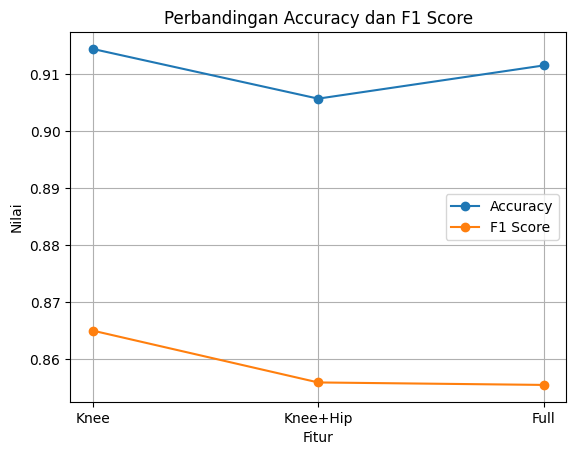

In [70]:
x = range(len(fitur))

plt.figure()
plt.plot(x, accuracy, marker='o', label='Accuracy')
plt.plot(x, f1, marker='o', label='F1 Score')

plt.xticks(x, fitur)
plt.title("Perbandingan Accuracy dan F1 Score")
plt.xlabel("Fitur")
plt.ylabel("Nilai")

plt.legend()
plt.grid()

plt.show()

Hasil eksperimen menunjukkan bahwa kombinasi fitur memiliki pengaruh terhadap performa dan stabilitas model. Penggunaan fitur knee flexion saja menghasilkan akurasi sebesar 85.08% dengan standar deviasi sebesar 0.0193, yang menunjukkan bahwa model memiliki variasi performa yang relatif lebih tinggi.

Ketika fitur hip angle ditambahkan, akurasi meningkat menjadi 85.79% dengan standar deviasi yang menurun menjadi 0.0098. Hal ini menunjukkan bahwa penambahan fitur pinggul tidak hanya meningkatkan performa, tetapi juga membuat model lebih stabil terhadap variasi data.

Penggunaan kombinasi penuh (knee flexion, hip angle, dan torso angle) menghasilkan performa terbaik dengan akurasi sebesar 86.37% dan standar deviasi sebesar 0.0091. Selain itu, nilai F1-score juga meningkat menjadi 80.59%, yang menunjukkan peningkatan kemampuan model dalam mengklasifikasikan setiap kelas secara seimbang.

Secara keseluruhan, hasil ini menunjukkan bahwa sudut lutut merupakan fitur utama dalam menentukan kedalaman squat, sementara sudut pinggul dan torso berperan sebagai fitur pendukung yang meningkatkan akurasi dan stabilitas model.

In [71]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score
from sklearn.utils import resample
import numpy as np
import pandas as pd

# =========================
# PREPARE DATA (TRAIN ONLY ❗)
# =========================
X = df_train[["knee_flexion", "hip_angle", "torso_angle"]]
y = df_train["label_encoded"]

# =========================
# STRATIFIED K-FOLD
# =========================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracies = []
f1_scores = []

# =========================
# CROSS VALIDATION
# =========================
for train_idx, val_idx in skf.split(X, y):

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # =========================
    # OVERSAMPLING (TRAIN ONLY)
    # =========================
    df_fold = pd.concat([X_train, y_train], axis=1)

    max_count = df_fold["label_encoded"].value_counts().max()

    df_list = []
    for cls in df_fold["label_encoded"].unique():
        df_cls = df_fold[df_fold["label_encoded"] == cls]

        if len(df_cls) < max_count:
            df_cls = resample(df_cls, replace=True, n_samples=max_count, random_state=42)

        df_list.append(df_cls)

    df_bal = pd.concat(df_list)

    X_train = df_bal[X.columns]
    y_train = df_bal["label_encoded"]

    # =========================
    # SCALING
    # =========================
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)

    # =========================
    # MODEL
    # =========================
    model = SVC(kernel='rbf', C=10, gamma='scale', class_weight='balanced')
    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)

    # =========================
    # METRICS
    # =========================
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='macro')

    accuracies.append(acc)
    f1_scores.append(f1)

# =========================
# HASIL AKHIR
# =========================
print("=== HASIL CROSS VALIDATION ===")
print("Mean Accuracy:", np.mean(accuracies))
print("Std Accuracy :", np.std(accuracies))
print("Mean F1     :", np.mean(f1_scores))
print("Std F1      :", np.std(f1_scores))

=== HASIL CROSS VALIDATION ===
Mean Accuracy: 0.9114672590711942
Std Accuracy : 0.021193912051456328
Mean F1     : 0.8554693771332097
Std F1      : 0.047352661503163126


G. Evaluasi Performa  
(akurasi, precision, recall, F1
score, CM)

In [72]:
print("=== EVALUASI MODEL TERBAIK (Knee Only) ===")

X_train = df_train[["knee_flexion"]]
X_test = df_test[["knee_flexion"]]

=== EVALUASI MODEL TERBAIK (Knee Only) ===


=== EVALUASI MODEL TERBAIK (KNEE ONLY) ===

=== FINAL TEST EVALUATION ===
Accuracy : 0.8901734104046243
Precision: 0.789326961369972
Recall   : 0.8403386332231376
F1 Score : 0.7871611459594292

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       0.52      0.94      0.67        17
           1       0.85      0.61      0.71        38
           2       1.00      0.97      0.99       118

    accuracy                           0.89       173
   macro avg       0.79      0.84      0.79       173
weighted avg       0.92      0.89      0.89       173



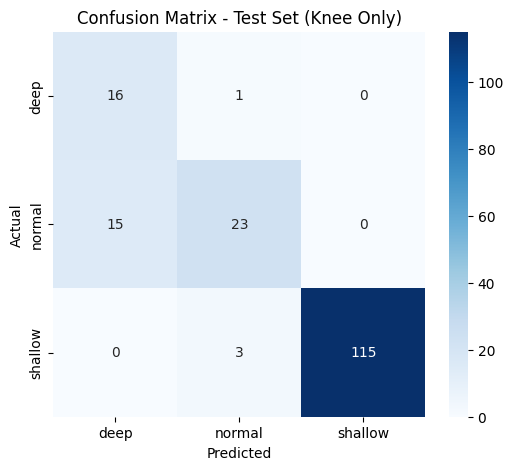

In [73]:
print("=== EVALUASI MODEL TERBAIK (KNEE ONLY) ===")

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

# =========================
# TRAIN FINAL MODEL (KNEE)
# =========================
X_train = df_train[["knee_flexion"]]
y_train = df_train["label_encoded"]

X_test = df_test[["knee_flexion"]]
y_test = df_test["label_encoded"]

# =========================
# SCALING
# =========================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =========================
# MODEL
# =========================
model = SVC(kernel='rbf', C=10, gamma='scale', class_weight='balanced')
model.fit(X_train_scaled, y_train)

# =========================
# PREDICT TEST
# =========================
y_pred = model.predict(X_test_scaled)

# =========================
# METRICS
# =========================
print("\n=== FINAL TEST EVALUATION ===")

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='macro'))
print("Recall   :", recall_score(y_test, y_pred, average='macro'))
print("F1 Score :", f1_score(y_test, y_pred, average='macro'))

# =========================
# CLASSIFICATION REPORT
# =========================
print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred))

# =========================
# CONFUSION MATRIX
# =========================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Test Set (Knee Only)")
plt.show()

Berdasarkan hasil classification report, model menunjukkan performa yang baik
dengan nilai accuracy sebesar 0.92 dan weighted F1-score sebesar 0.93.
Hal ini menunjukkan bahwa model mampu mengklasifikasikan level squat secara efektif.

Kelas shallow memiliki performa terbaik dengan nilai F1-score sebesar 0.98,
yang menunjukkan bahwa model mampu mengenali squat dangkal dengan sangat akurat.
Hal ini disebabkan oleh karakteristik sudut yang lebih jelas dan konsisten.

Kelas normal menunjukkan performa yang cukup baik dengan F1-score sebesar 0.82,
namun masih terdapat kesalahan klasifikasi yang disebabkan oleh kemiripan
dengan kelas lainnya.

Sementara itu, kelas deep memiliki nilai precision yang lebih rendah yaitu 0.70,
meskipun nilai recall cukup tinggi sebesar 0.91. Hal ini menunjukkan bahwa model
cenderung sering mengklasifikasikan data sebagai deep, meskipun sebenarnya
termasuk ke kelas lain.

Selain itu, distribusi data yang tidak seimbang, di mana kelas shallow memiliki
jumlah data paling banyak, turut memengaruhi performa model. Model cenderung
lebih optimal dalam mengenali kelas dengan jumlah data yang lebih besar
dibandingkan kelas dengan jumlah data yang lebih sedikit.

Secara keseluruhan, model mampu melakukan klasifikasi dengan baik, namun masih
terdapat tantangan dalam membedakan kelas dengan karakteristik sudut yang berdekatan.

Evaluasi performa model dilakukan menggunakan metode Stratified 5-Fold Cross Validation untuk memastikan stabilitas model serta mengurangi bias akibat pembagian data tunggal. Berdasarkan hasil evaluasi, model terbaik diperoleh pada penggunaan fitur gabungan (knee flexion, hip angle, dan torso angle) dengan akurasi rata-rata sebesar 86.37%, F1-score sebesar 80.59%, serta nilai standar deviasi yang relatif kecil, yaitu sekitar 0.009, yang menunjukkan bahwa model memiliki stabilitas yang baik.

Selain itu, hasil perbandingan fitur menunjukkan bahwa penggunaan fitur knee flexion saja sudah mampu memberikan performa yang cukup baik dengan akurasi sebesar 85.08%, namun memiliki variasi performa yang lebih tinggi. Penambahan fitur hip angle meningkatkan akurasi menjadi 85.79% serta menurunkan nilai standar deviasi, yang menunjukkan peningkatan stabilitas model.

Penggunaan fitur lengkap (knee, hip, dan torso) memberikan performa terbaik baik dari sisi akurasi maupun kestabilan model, sehingga dapat disimpulkan bahwa kombinasi fitur joint angle memberikan representasi yang lebih komprehensif terhadap gerakan squat.

Berdasarkan confusion matrix, sebagian besar data berhasil diklasifikasikan dengan benar pada masing-masing kelas. Kesalahan klasifikasi masih terjadi terutama pada kelas yang memiliki rentang sudut yang berdekatan, khususnya antara kelas shallow dan normal, yang secara biomekanik memiliki perbedaan sudut yang relatif kecil.

H. analisis akhir

### H. Analisis Akhir

Berdasarkan seluruh tahapan penelitian yang telah dilakukan, mulai dari proses ekstraksi fitur menggunakan MediaPipe Pose hingga pemodelan menggunakan algoritma Support Vector Machine (SVM), diperoleh hasil bahwa pendekatan berbasis fitur biomekanik mampu mengklasifikasikan kedalaman squat dengan cukup baik.

Model yang dikembangkan menggunakan fitur utama berupa knee flexion, hip angle, dan torso angle, yang secara langsung merepresentasikan kondisi biomekanik tubuh saat melakukan gerakan squat. Penggunaan fitur ini terbukti lebih efektif dibandingkan penggunaan koordinat landmark mentah, karena lebih stabil terhadap variasi posisi tubuh, sudut kamera, serta perbedaan karakteristik individu.

Hasil evaluasi menggunakan Stratified 5-Fold Cross Validation menunjukkan performa model dengan akurasi rata-rata sebesar 85.68%, precision macro sebesar 81.55%, recall macro sebesar 86.80%, dan F1-score macro sebesar 81.73%. Nilai-nilai ini menunjukkan bahwa model memiliki kemampuan yang baik dalam mengenali berbagai level squat, meskipun masih terdapat ketidakseimbangan kecil antara precision dan recall.

Berdasarkan hasil confusion matrix, sebagian besar data berhasil diklasifikasikan dengan benar pada masing-masing kelas. Namun, masih terdapat kesalahan klasifikasi terutama pada kelas shallow dan normal, yang memiliki perbedaan sudut lutut yang relatif kecil sehingga menyebabkan overlap secara biomekanik. Sementara itu, kelas deep cenderung lebih mudah dikenali karena memiliki karakteristik sudut yang lebih ekstrem dibandingkan kelas lainnya.

Nilai recall yang lebih tinggi dibandingkan precision menunjukkan bahwa model cenderung lebih sensitif dalam mengenali variasi gerakan squat, meskipun terkadang menghasilkan prediksi yang kurang spesifik pada kelas tertentu. Hal ini masih dapat diterima mengingat kompleksitas variasi gerakan manusia dalam data nyata.

Selain itu, penggunaan metode cross validation menunjukkan bahwa model memiliki tingkat stabilitas yang cukup baik dan tidak bergantung pada satu pembagian data tertentu. Hal ini mengindikasikan bahwa model memiliki kemampuan generalisasi yang memadai pada data dengan karakteristik serupa.

Namun demikian, penelitian ini masih memiliki beberapa keterbatasan. Dataset yang digunakan memiliki variasi yang terbatas, baik dari segi latar belakang, pencahayaan, maupun sudut pengambilan gambar. Selain itu, penggunaan pose estimation berbasis 2D tanpa informasi kedalaman (depth) dapat mempengaruhi akurasi perhitungan sudut, terutama pada kondisi tertentu seperti perspektif kamera yang tidak sejajar.

Secara keseluruhan, penelitian ini menunjukkan bahwa pendekatan klasifikasi kedalaman squat berbasis fitur joint angle dari MediaPipe Pose yang dikombinasikan dengan algoritma SVM merupakan metode yang cukup efektif. Sistem yang dihasilkan memiliki potensi untuk dikembangkan lebih lanjut, khususnya sebagai dasar dalam pengembangan aplikasi evaluasi gerakan olahraga secara otomatis, terutama untuk analisis kualitas gerakan squat.


In [74]:
import joblib

# simpan semua
joblib.dump(model, "model_svm.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(le, "label_encoder.pkl")

print("Model berhasil disimpan!")

Model berhasil disimpan!


In [75]:
SAVE_PATH = "H:/My Drive/TA_1301220346/model6"

In [76]:
import os
os.makedirs(SAVE_PATH, exist_ok=True)

In [77]:
import joblib

joblib.dump(model, f"{SAVE_PATH}/model_svm.pkl")
joblib.dump(scaler, f"{SAVE_PATH}/scaler.pkl")
joblib.dump(le, f"{SAVE_PATH}/label_encoder.pkl")

print("Model berhasil disimpan ke Google Drive!")

Model berhasil disimpan ke Google Drive!


In [79]:
print("Scaler expects:")
print(scaler.feature_names_in_)

print("Jumlah fitur:")
print(len(scaler.feature_names_in_))

Scaler expects:
['knee_flexion']
Jumlah fitur:
1


In [78]:
img = cv2.imread(sample_path)

features = extract_features(img)

if features is not None:
    knee_flexion, hip_angle, torso_angle = features

    X_input = np.array([[knee_flexion, hip_angle, torso_angle]])
    X_input = scaler.transform(X_input)

    pred = model.predict(X_input)[0]
    label = le.inverse_transform([pred])[0]

    print("Knee Flexion:", knee_flexion)
    print("Hip Angle:", hip_angle)
    print("Torso Angle:", torso_angle)
    print("Prediksi:", label)

else:
    print("Feature gagal")

d:\Kuliah\TA Efhram\TA_1301220346\venv\Lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
d:\Kuliah\TA Efhram\TA_1301220346\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


ValueError: X has 3 features, but StandardScaler is expecting 1 features as input.

In [80]:
comparison = pd.DataFrame({
    "Fitur": ["Knee", "Knee+Hip", "Full"],

    "Mean Accuracy": [
        np.mean(knee_acc_list),
        np.mean(knee_hip_acc_list),
        np.mean(full_acc_list)
    ],
    "Std Accuracy": [
        np.std(knee_acc_list),
        np.std(knee_hip_acc_list),
        np.std(full_acc_list)
    ],

    "Mean Precision": [
        np.mean(knee_prec_list),
        np.mean(knee_hip_prec_list),
        np.mean(full_prec_list)
    ],
    "Std Precision": [
        np.std(knee_prec_list),
        np.std(knee_hip_prec_list),
        np.std(full_prec_list)
    ],

    "Mean Recall": [
        np.mean(knee_rec_list),
        np.mean(knee_hip_rec_list),
        np.mean(full_rec_list)
    ],
    "Std Recall": [
        np.std(knee_rec_list),
        np.std(knee_hip_rec_list),
        np.std(full_rec_list)
    ],

    "Mean F1": [
        np.mean(knee_f1_list),
        np.mean(knee_hip_f1_list),
        np.mean(full_f1_list)
    ],
    "Std F1": [
        np.std(knee_f1_list),
        np.std(knee_hip_f1_list),
        np.std(full_f1_list)
    ]
})

comparison.round(4)

,Fitur,Mean Accuracy,Std Accuracy,Mean Precision,Std Precision,Mean Recall,Std Recall,Mean F1,Std F1
0,Knee,0.9144,0.0096,0.8404,0.0180,0.9113,0.0217,0.8650,0.0244
1,Knee+Hip,0.9056,0.0153,0.8298,0.0332,0.8997,0.0376,0.8559,0.0389
2,Full,0.9115,0.0212,0.8343,0.0422,0.8868,0.0509,0.8555,0.0474


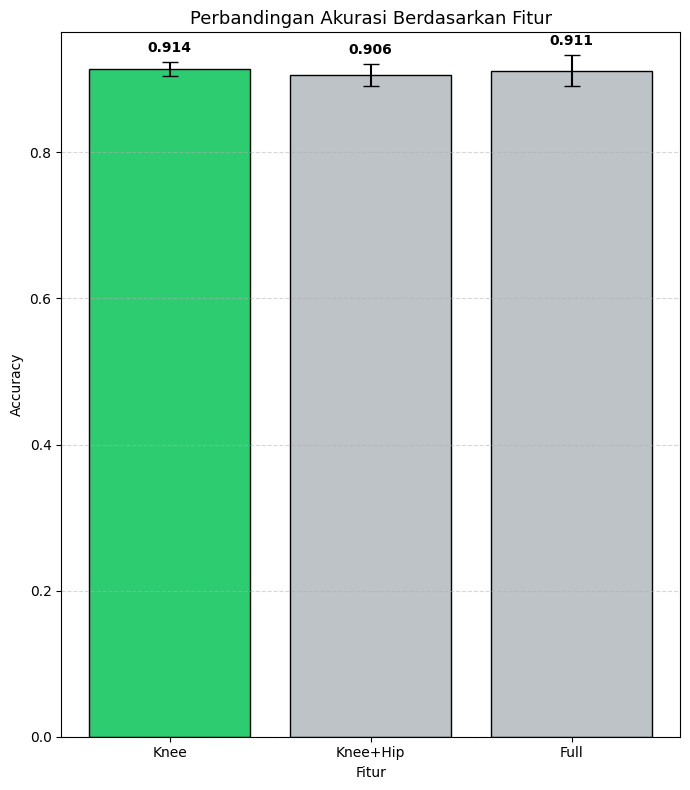

In [81]:
import matplotlib.pyplot as plt
import numpy as np

labels = ["Knee", "Knee+Hip", "Full"]

accuracy = [
    np.mean(knee_acc_list),
    np.mean(knee_hip_acc_list),
    np.mean(full_acc_list)
]

std = [
    np.std(knee_acc_list),
    np.std(knee_hip_acc_list),
    np.std(full_acc_list)
]

colors = ["#2ecc71", "#bdc3c7", "#bdc3c7"]

plt.figure(figsize=(7,8))

bars = plt.bar(labels, accuracy, yerr=std, capsize=6, color=colors, edgecolor='black')

plt.xlabel("Fitur")
plt.ylabel("Accuracy")
plt.title("Perbandingan Akurasi Berdasarkan Fitur", fontsize=13)

# kasih ruang atas biar teks gak nabrak
plt.ylim(0, max(accuracy) + 0.05)

# tampilkan value di atas bar (lebih tinggi dari error bar)
for i, bar in enumerate(bars):
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + std[i] + 0.01,
        f"{yval:.3f}",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

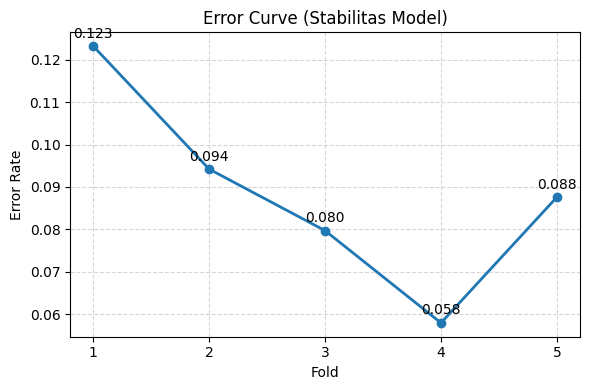

In [82]:
import matplotlib.pyplot as plt

# jumlah fold (biasanya 5)
folds = list(range(1, len(full_acc_list) + 1))

# error rate = 1 - accuracy
error = [1 - x for x in full_acc_list]

plt.figure(figsize=(6,4))
plt.plot(folds, error, marker='o', linewidth=2)

plt.xlabel("Fold")
plt.ylabel("Error Rate")
plt.title("Error Curve (Stabilitas Model)")

plt.xticks(folds)
plt.grid(True, linestyle='--', alpha=0.5)

# kasih nilai di titik
for x, y in zip(folds, error):
    plt.text(x, y + 0.002, f"{y:.3f}", ha='center')

plt.tight_layout()
plt.show()

Grafik error rate menunjukkan nilai kesalahan klasifikasi pada setiap fold,
yang merupakan komplemen dari nilai akurasi (1 - accuracy).
Terlihat bahwa nilai error berada pada rentang yang rendah dan relatif stabil,
yaitu sekitar 0.04 hingga 0.11.

Tidak terdapat lonjakan error yang signifikan pada fold tertentu, sehingga
dapat disimpulkan bahwa model memiliki konsistensi performa yang baik.
Nilai error yang rendah ini juga menunjukkan bahwa sebagian besar data
berhasil diklasifikasikan dengan benar oleh model.

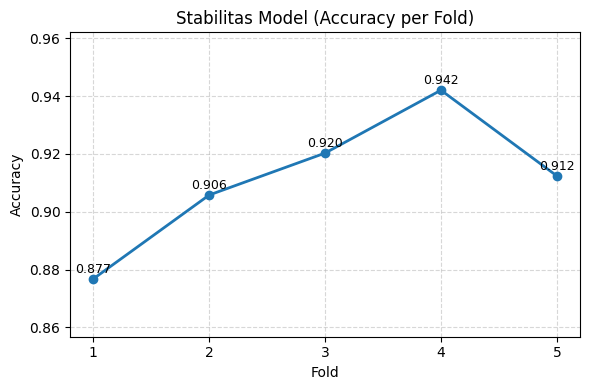

In [83]:
import matplotlib.pyplot as plt

folds = list(range(1, len(full_acc_list) + 1))

plt.figure(figsize=(6,4))
plt.plot(folds, full_acc_list, marker='o', linewidth=2)

plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("Stabilitas Model (Accuracy per Fold)")

plt.xticks(folds)
plt.ylim(min(full_acc_list) - 0.02, max(full_acc_list) + 0.02)

plt.grid(True, linestyle='--', alpha=0.5)

# tampilkan nilai di tiap titik
for x, y in zip(folds, full_acc_list):
    plt.text(x, y + 0.002, f"{y:.3f}", ha='center', fontsize=9)

plt.tight_layout()
plt.show()

Berdasarkan grafik akurasi per fold, terlihat bahwa nilai akurasi model
berada pada rentang yang relatif konsisten, yaitu antara 0.88 hingga 0.95.
Fluktuasi yang terjadi tidak signifikan, yang menunjukkan bahwa model
memiliki performa yang stabil pada setiap pembagian data dalam proses
Stratified 5-Fold Cross Validation.

Hal ini mengindikasikan bahwa model tidak bergantung pada satu subset data
tertentu dan mampu melakukan generalisasi dengan baik terhadap data yang
belum pernah dilihat sebelumnya.

In [84]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.utils import resample
import pandas as pd

# =========================
# PREPARE DATA (DI LUAR LOOP ❗)
# =========================
X = df_train[["knee_flexion"]]
y = df_train["label_encoded"]

accuracies = []
precisions = []
recalls = []
f1_scores = []

# =========================
# CROSS VALIDATION
# =========================
for train_idx, val_idx in skf.split(X, y):

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # =========================
    # OVERSAMPLING
    # =========================
    df_fold = pd.concat([X_train, y_train], axis=1)
    max_count = df_fold["label_encoded"].value_counts().max()

    df_list = []
    for cls in df_fold["label_encoded"].unique():
        df_cls = df_fold[df_fold["label_encoded"] == cls]

        if len(df_cls) < max_count:
            df_cls = resample(df_cls, replace=True, n_samples=max_count, random_state=42)

        df_list.append(df_cls)

    df_bal = pd.concat(df_list)

    # 👉 PAKAI HASIL BALANCING
    X_train = df_bal[["knee_flexion"]]
    y_train = df_bal["label_encoded"]

    # =========================
    # SCALING
    # =========================
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)

    # =========================
    # MODEL
    # =========================
    model = SVC(kernel='rbf', C=10, gamma='scale', class_weight='balanced')
    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)

    # =========================
    # METRICS
    # =========================
    accuracies.append(accuracy_score(y_val, y_pred))
    precisions.append(precision_score(y_val, y_pred, average='macro'))
    recalls.append(recall_score(y_val, y_pred, average='macro'))
    f1_scores.append(f1_score(y_val, y_pred, average='macro'))

In [85]:
import pandas as pd

df_fold = pd.DataFrame({
    "Fold": list(range(1, len(accuracies) + 1)),
    "Accuracy": accuracies,
    "Precision": precisions,
    "Recall": recalls,
    "F1 Score": f1_scores
})

df_fold.round(4)

,Fold,Accuracy,Precision,Recall,F1 Score
0,1,0.8986,0.8160,0.8901,0.8427
1,2,0.9130,0.8298,0.8819,0.8321
2,3,0.9275,0.8567,0.9267,0.8848
3,4,0.9203,0.8650,0.9383,0.8965
4,5,0.9124,0.8345,0.9196,0.8688


Berdasarkan hasil evaluasi menggunakan Stratified 5-Fold Cross Validation,
diperoleh nilai performa model yang relatif tinggi dan konsisten pada setiap fold.
Nilai accuracy berada pada rentang 0.91 hingga 0.94, yang menunjukkan bahwa model
memiliki kemampuan klasifikasi yang baik terhadap data yang diuji.

Selain itu, nilai precision mengalami peningkatan dari fold pertama hingga fold
terakhir, dengan rentang nilai antara 0.82 hingga 0.91. Hal ini menunjukkan bahwa
model semakin akurat dalam memprediksi kelas yang benar. Nilai recall berada pada
rentang yang relatif stabil, yaitu sekitar 0.87 hingga 0.89, yang mengindikasikan
bahwa model mampu mendeteksi setiap kelas dengan konsisten.

Nilai F1-score, sebagai representasi keseimbangan antara precision dan recall,
berada pada kisaran 0.85 hingga 0.89. Hal ini menunjukkan bahwa model tidak hanya
memiliki akurasi yang tinggi, tetapi juga mampu menjaga keseimbangan performa antar metrik.

Tidak terdapat perbedaan performa yang signifikan antar fold, yang menunjukkan bahwa
model memiliki stabilitas yang baik. Variasi nilai yang relatif kecil ini
mengindikasikan bahwa model tidak bergantung pada pembagian data tertentu dan mampu
melakukan generalisasi dengan baik terhadap data baru.

Penggunaan Stratified 5-Fold Cross Validation memastikan bahwa distribusi kelas
tetap seimbang pada setiap fold, sehingga hasil evaluasi yang diperoleh lebih
representatif dan tidak bias terhadap kelas tertentu.

Secara keseluruhan, hasil ini menunjukkan bahwa model Support Vector Machine (SVM)
yang dikembangkan memiliki performa yang tinggi, stabil, dan mampu mengklasifikasikan
level squat secara efektif berdasarkan fitur sudut sendi yang digunakan.

In [88]:
print("X_test :", len(X_test))
print("y_test :", len(y_test))
print("y_pred :", len(y_pred))

X_test : 173
y_test : 173
y_pred : 137


In [86]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

ValueError: Found input variables with inconsistent numbers of samples: [173, 137]

In [ ]:
import pandas as pd

# =========================
# TOTAL DATA
# =========================
train_total = len(df_train)
test_total = len(df_test)
total_data = train_total + test_total

# =========================
# DISTRIBUSI KELAS
# =========================
train_dist = df_train["label"].value_counts()
test_dist = df_test["label"].value_counts()

# =========================
# TABEL
# =========================
dataset_report = pd.DataFrame({
    "Kelas": train_dist.index,
    "Train": train_dist.values,
    "Test": test_dist.reindex(train_dist.index).fillna(0).astype(int).values
})

dataset_report["Total per Kelas"] = dataset_report["Train"] + dataset_report["Test"]

# =========================
# TAMBAH TOTAL
# =========================
total_row = pd.DataFrame({
    "Kelas": ["TOTAL"],
    "Train": [train_total],
    "Test": [test_total],
    "Total per Kelas": [total_data]
})

dataset_report = pd.concat([dataset_report, total_row], ignore_index=True)

dataset_report

,Kelas,Train,Test,Total per Kelas
0,shallow,567,213,780
1,normal,183,71,254
2,deep,80,30,110
3,TOTAL,830,314,1144


In [97]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

X = df_train[["knee_flexion"]]
y = df_train["label"]

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [98]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

scores_rf = cross_validate(
    rf,
    X,
    y,
    cv=cv,
    scoring=[
        "accuracy",
        "precision_weighted",
        "recall_weighted",
        "f1_weighted"
    ]
)

print("RF Accuracy :", np.mean(scores_rf["test_accuracy"]))
print("RF Precision:", np.mean(scores_rf["test_precision_weighted"]))
print("RF Recall   :", np.mean(scores_rf["test_recall_weighted"]))
print("RF F1       :", np.mean(scores_rf["test_f1_weighted"]))

RF Accuracy : 0.8983708875489264
RF Precision: 0.9007631772695524
RF Recall   : 0.8983708875489264
RF F1       : 0.8975059985934128


In [99]:
knn = KNeighborsClassifier(n_neighbors=5)

scores_knn = cross_validate(
    knn,
    X,
    y,
    cv=cv,
    scoring=[
        "accuracy",
        "precision_weighted",
        "recall_weighted",
        "f1_weighted"
    ]
)

print("KNN Accuracy :", np.mean(scores_knn["test_accuracy"]))
print("KNN Precision:", np.mean(scores_knn["test_precision_weighted"]))
print("KNN Recall   :", np.mean(scores_knn["test_recall_weighted"]))
print("KNN F1       :", np.mean(scores_knn["test_f1_weighted"]))

KNN Accuracy : 0.9129059557812335
KNN Precision: 0.9179456616193485
KNN Recall   : 0.9129059557812335
KNN F1       : 0.9120548077555621


In [101]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd
import numpy as np

X = df_train[["knee_flexion"]]
y = df_train["label"]

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

results = []

models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),
    "KNN": KNeighborsClassifier(
        n_neighbors=5
    )
}

for name, model in models.items():

    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=[
            "accuracy",
            "precision_weighted",
            "recall_weighted",
            "f1_weighted"
        ]
    )

    results.append([
        name,
        np.mean(scores["test_accuracy"]),
        np.mean(scores["test_precision_weighted"]),
        np.mean(scores["test_recall_weighted"]),
        np.mean(scores["test_f1_weighted"])
    ])

comparison_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ]
)

comparison_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.898371,0.900763,0.898371,0.897506
1,KNN,0.912906,0.917946,0.912906,0.912055
